### Inferring parameters for the dependence of $N_{steps}^{limit}$ on several parameters

The form that seems to work is 

$$
N_{steps}^{limit} = N_{combined} \times c_r^{m_{c_r}} \times \omega_{kin}^{m_{\omega}} \times D_{QLL}^{m_D}
$$

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams
import time
from copy import copy as dup
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from pint import UnitRegistry; AssignQuantity = UnitRegistry().Quantity
from importlib import reload
from matplotlib.gridspec import GridSpec

# My modules
import sys; sys.path.append('..')
import importlib  # Import the importlib module
import QLCstuff as QLC
import f90nml

In [3]:
# Graphics parameters
%matplotlib inline
ticklabelsize = 11
fontsize = 15
linewidth = 2
markersize = 15

In [4]:
# Get default parameters
GIfile = '../GI parameters - Table 1.nml'
sigmaI_corner_ref, sigma0_ref, cr_ref, sigmaI_QLC_ref, Nbar_ref, Nstar_ref, h_layer_ref, D_ref, nu_kin_ref, L_ref, nx_crystal_ref, t_eq_ref, x_QLC_ref, DoverL2pi2_ref, Doverdeltax2_ref = \
    QLC.get_system_parameters(GIfile, AssignQuantity)
print('\nConverting to dimensionless ...')
cr_ref.ito('dimensionless'); print(cr_ref)
sigma0_ref.ito('dimensionless'); print(sigma0_ref)
sigmaI_QLC_ref.ito('dimensionless'); print(sigmaI_QLC_ref[0])
odemethod_ref, tkeep_1Darr_ref, Ntot_init_1D_ref, NQLL_init_1D_ref = \
    QLC.get_runtime_parameters(GIfile, nx_crystal_ref, Nstar_ref, Nbar_ref, AssignQuantity)


Using parameter file ../GI parameters - Table 1.nml ...
sigmaI_corner = 22 percent
sigma0 = 20 percent
c_r = 0.2 percent
Nbar 1
Nstar 0.1
h_layer = 0.37 nanometer
D = 0.0002 micrometer ** 2 / microsecond
nu_kin = 0.264 / microsecond
L = 50 micrometer
nx (crystal) = 501
t_eq = 1.5 microsecond
Spacing of points on the ice surface = 0.20000000000000284 micrometer
omega_kin = 0.396 dimensionless

Converting to dimensionless ...
0.002 dimensionless
0.2 dimensionless
0.22 dimensionless

Using parameter file ../GI parameters - Table 1.nml ...
runtime = 300 millisecond
odemethod = RK45
This is a run from time 0.0 millisecond to 300.0 millisecond
dt = 6122.448979591837 microsecond


In [5]:
# Loading 
crfile = 'Nsteps_limit(cr).txt'
cr_range, Nsteps_cr_range = np.loadtxt(crfile)
cr_range /= 100 # Assumes it was saved as a %
print('cr_range',cr_range)
print('Nsteps_cr_range',Nsteps_cr_range)

omega_file = 'Nsteps_limit(omega_kin).txt'
omega_range, Nsteps_omega_range = np.loadtxt(omega_file)
print('omega_range',omega_range); print('shape',np.shape(omega_range))
print('Nsteps_omega_range',Nsteps_omega_range); print('shape',np.shape(Nsteps_omega_range))

Dfile = 'Nsteps_limit(D).txt'
D_range, Nsteps_D_range = np.loadtxt(Dfile)
print('D_range',D_range)
print('Nsteps_D_range',Nsteps_D_range)

cr_range [0.0005     0.00068889 0.00087778 0.00106667 0.00125556 0.00144444
 0.00163333 0.00182222 0.00201111 0.0022    ]
Nsteps_cr_range [10.02339304 11.97239721 13.40632429 14.96487948 16.05506617 17.14234431
 18.22605557 19.25405162 20.22291052 21.18890781]
omega_range [0.099  0.1364 0.1738 0.2112 0.2486 0.286  0.3234 0.3608 0.3982 0.4356]
shape (10,)
Nsteps_omega_range [ 9.05748578 10.98020766 12.35550277 14.01744898 15.56079086 16.46965669
 18.08587277 19.4983042  20.22011489 21.91346735]
shape (10,)
D_range [0.00012    0.00013818 0.00015636 0.00017455 0.00019273 0.00021091
 0.00022909 0.00024727 0.00026545 0.00028364 0.00030182 0.00032   ]
Nsteps_D_range [26.73841502 24.80256107 23.40571169 21.9254959  20.88618438 19.94092031
 19.32646766 18.72288379 17.8424495  17.5102853  16.80419677 16.49620561]


From fit ...  [0.49842651 6.10399567]
Nsteps_cr_ref 20.215916999820962
m = 0.4984265071646885
using m_cr 0.498
Nsteps_cr_factor = 447.64283551914144


/Users/nesh/anaconda3/lib/python3.10/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


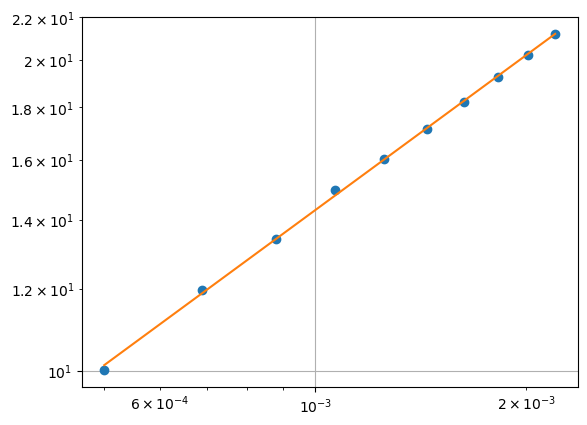

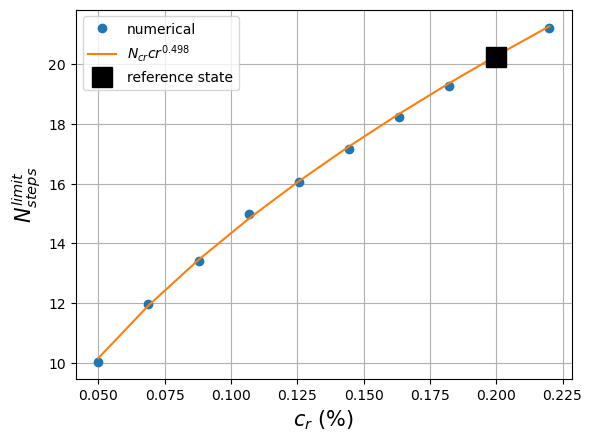

In [6]:
# Working on Nsteps as a function of cr

# Plot as a log-log, and fit
plt.figure()
plt.loglog(cr_range,Nsteps_cr_range,'o')
x = np.log(cr_range)
y = np.log(Nsteps_cr_range)
p = np.polyfit(x,y,1); print('From fit ... ', p)
m = p[0]; b = p[1]
logcr = np.polyval(p,x)
cr_fit = np.exp(logcr)
plt.loglog(cr_range,cr_fit)
plt.grid(True)

# Get the reference state value
x_ref = np.log(cr_ref)
log_y_ref = np.polyval(p,x_ref.magnitude)
Nsteps_cr_ref = np.exp(log_y_ref); print('Nsteps_cr_ref', Nsteps_cr_ref)

plt.figure()
print('m =',m)
m_cr = np.round(m,3); print('using m_cr',m_cr)
m_cr_label = '$N_{cr} cr^{'+str(m_cr)+'}$'
Nsteps_cr_factor = np.exp(b); print('Nsteps_cr_factor =',Nsteps_cr_factor)
Nsteps_cr_range_fit = Nsteps_cr_factor*cr_range**m_cr
plt.plot(cr_range*100,Nsteps_cr_range,'o',label='numerical')
plt.plot(cr_range*100,Nsteps_cr_range_fit,label=m_cr_label)
plt.plot(cr_ref*100,Nsteps_cr_ref,'s',markersize=markersize,color='k',label='reference state')
plt.xlabel("$c_r \ (\%)$",fontsize=fontsize)
plt.ylabel('$N_{steps}^{limit}$',fontsize=fontsize)
plt.legend()
plt.grid(True)

figfilename = 'Nsteps_limit(cr).png'
plt.savefig(figfilename,dpi=200)

omega_range [0.099  0.1364 0.1738 0.2112 0.2486 0.286  0.3234 0.3608 0.3982 0.4356]
shape (10,)
Nsteps_omega_range [ 9.05748578 10.98020766 12.35550277 14.01744898 15.56079086 16.46965669
 18.08587277 19.4983042  20.22011489 21.91346735]
shape (10,)
[0.58909264 3.55972666]
omega_kin_ref 0.396 dimensionless
Nsteps_omega_kin_ref 20.36924078790805
m = 0.5890926403279386
using m_omega 0.589
Nsteps_omega_factor = 35.15358708691115


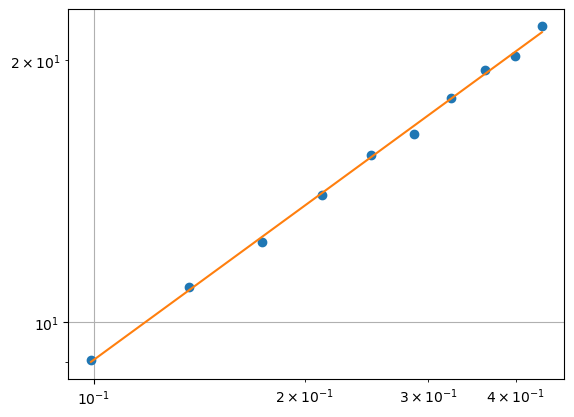

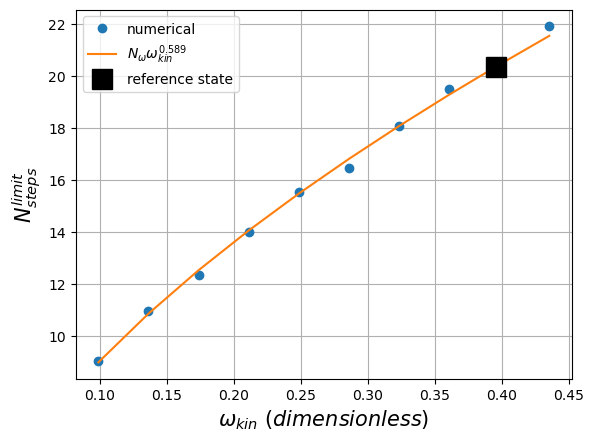

In [7]:
# Working on Nsteps as a function of omega

print('omega_range',omega_range); print('shape',np.shape(omega_range))
print('Nsteps_omega_range',Nsteps_omega_range); print('shape',np.shape(Nsteps_omega_range))

# Plot as a log-log
plt.figure()
plt.loglog(omega_range,Nsteps_omega_range,'o')
x = np.log(omega_range)
y = np.log(Nsteps_omega_range)
p = np.polyfit(x,y,1); print(p)
m = p[0]; b = p[1]
logNsteps = np.polyval(p,x)
Nsteps_fit = np.exp(logNsteps)
plt.loglog(omega_range,Nsteps_fit)
plt.grid(True)

# Get the reference state value
omega_kin_ref = t_eq_ref*nu_kin_ref; print('omega_kin_ref',omega_kin_ref)
x_ref = x = np.log(omega_kin_ref)
log_y_ref = np.polyval(p,x_ref.magnitude)
Nsteps_omega_kin_ref = np.exp(log_y_ref); print('Nsteps_omega_kin_ref', Nsteps_omega_kin_ref)

plt.figure()
print('m =',m)
m_omega = np.round(m,3); print('using m_omega',m_omega)
m_omega_label = '$N_{\omega} \omega_{kin}^{'+str(m_omega)+'}$'
Nsteps_omega_factor = np.exp(b); print('Nsteps_omega_factor =',Nsteps_omega_factor)
Nsteps_omega_range_fit = Nsteps_omega_factor*omega_range**m_omega
plt.plot(omega_range,Nsteps_omega_range,'o',label='numerical')
plt.plot(omega_range,Nsteps_omega_range_fit,label=m_omega_label)
plt.plot(omega_kin_ref,Nsteps_omega_kin_ref,'s',markersize=markersize,color='k',label='reference state')
plt.xlabel('$\omega_{kin} \ (dimensionless)$',fontsize=fontsize)
plt.ylabel('$N_{steps}^{limit}$',fontsize=fontsize)
plt.legend()
plt.grid(True)

figfilename = 'Nsteps_limit(omega).png'
plt.savefig(figfilename,dpi=200,bbox_inches="tight")

From fit ...  [-0.49272226 -1.16885883]
Nsteps_D_ref 20.650755170343583
m = -0.49272226426396454
using m_D -0.493
Nsteps_D_factor = 0.31072132620604825


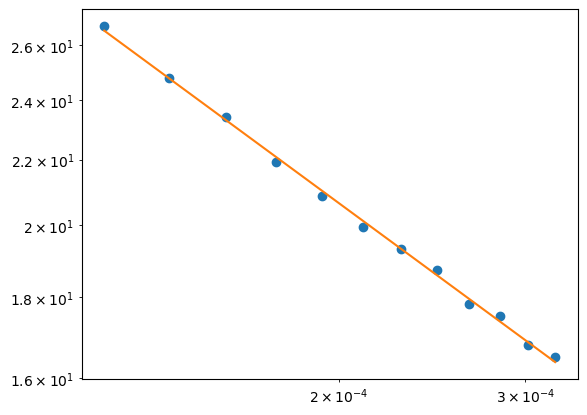

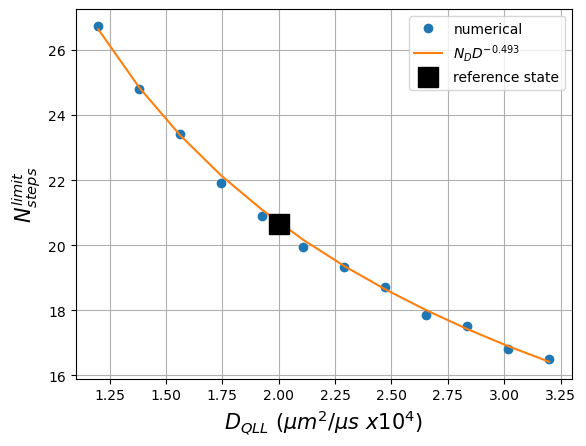

In [20]:
# Working on Nsteps as a function of D

# Plot as a log-log, and fit
plt.figure()
plt.loglog(D_range,Nsteps_D_range,'o')
x = np.log(D_range)
y = np.log(Nsteps_D_range)
p = np.polyfit(x,y,1); print('From fit ... ', p)
m = p[0]; b = p[1]
logD = np.polyval(p,x)
D_fit = np.exp(logD)
plt.loglog(D_range,D_fit)
plt.grid(True)

# Get the reference state value
x_ref = np.log(D_ref.magnitude)
log_y_ref = np.polyval(p,x_ref)
Nsteps_D_ref = np.exp(log_y_ref); print('Nsteps_D_ref', Nsteps_D_ref)

plt.figure()
print('m =',m)
m_D = np.round(m,3); print('using m_D',m_D)
m_D_label = '$N_{D} D^{'+str(m_D)+'}$'
Nsteps_D_factor = np.exp(b); print('Nsteps_D_factor =',Nsteps_D_factor)
Nsteps_D_range_fit = Nsteps_D_factor*D_range**m_D
plt.plot(D_range*1e4,Nsteps_D_range,'o',label='numerical')
plt.plot(D_range*1e4,Nsteps_D_range_fit,label=m_D_label)
plt.plot(D_ref*1e4,Nsteps_D_ref,'s',markersize=markersize,color='k',label='reference state')
plt.xlabel("$D_{QLL} \ ({\mu m^2 / \mu s}\ x 10^{4}) $",fontsize=fontsize)
plt.ylabel('$N_{steps}^{limit}$',fontsize=fontsize)
plt.legend()
plt.grid(True)

figfilename = 'Nsteps_limit(D).png'
plt.savefig(figfilename,dpi=200)

### Combining forms

20.215916999820962 20.650755170343583 20.36924078790805
0.002 dimensionless 0.396 dimensionless 0.0002 micrometer ** 2 / microsecond
powers 0.498 0.589 -0.493
Nsteps_ref_avg 20.4119709860242
Nsteps_factor 11.7 dimensionless


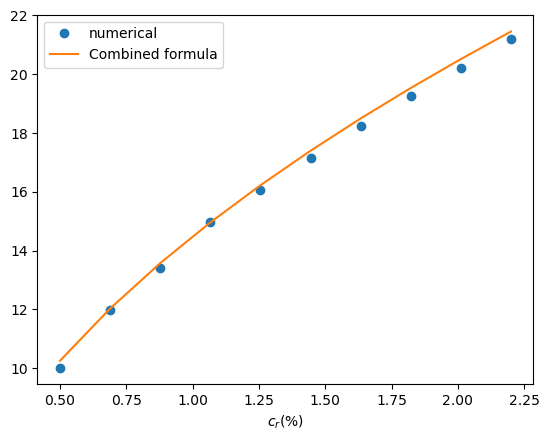

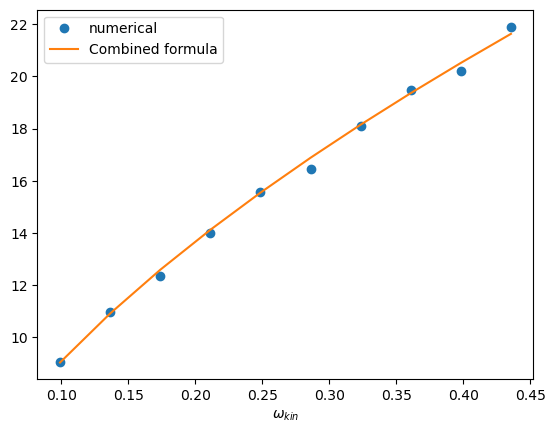

In [10]:
print(Nsteps_cr_ref,Nsteps_D_ref,Nsteps_omega_kin_ref)
print(cr_ref,omega_kin_ref,D_ref)
print('powers', m_cr,m_omega,m_D)
Nsteps_ref_avg = np.mean((Nsteps_cr_ref,Nsteps_D_ref,Nsteps_omega_kin_ref))
print('Nsteps_ref_avg',Nsteps_ref_avg)
Nsteps_factor = Nsteps_ref_avg/(cr_ref**m_cr * omega_kin_ref**m_omega * D_ref.magnitude**m_D)
Nsteps_factor = np.round(Nsteps_factor,1)
print('Nsteps_factor', Nsteps_factor)

# Let's test this
plt.figure()
plt.plot(cr_range*1000,Nsteps_cr_range,'o',label='numerical')
Nsteps_combined_test_1 = Nsteps_factor *cr_range**m_cr *omega_kin_ref**m_omega *D_ref**m_D
plt.plot(cr_range*1000,Nsteps_combined_test_1,label='Combined formula')
plt.xlabel('$c_r (\%)$')
plt.legend()

plt.figure()
plt.plot(omega_range,Nsteps_omega_range,'o',label='numerical')
Nsteps_combined_test_2 = Nsteps_factor *cr_ref**m_cr   *omega_range**m_omega  *D_ref**m_D
plt.plot(omega_range,Nsteps_combined_test_2,label='Combined formula')
plt.xlabel('$\omega_{kin}$')
plt.legend()